c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


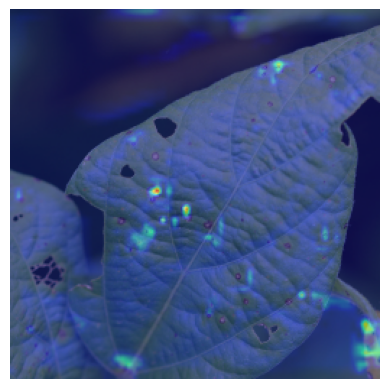

In [5]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load your trained custom CNN model
model = tf.keras.models.load_model(r"..\Models\inference_model.keras")

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model")

def preprocess_image(img_path, image_size):
    # Read and resize only once
    img = cv2.imread(img_path)
    img = cv2.resize(img, (image_size, image_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
    img_array = np.expand_dims(img, axis=0).astype(np.float32)
    return img, img_array  # Return both original and processed

def grad_cam_plus_plus(model, img_array, layer_name, class_index):
    grad_model = tf.keras.models.Model(
        inputs=[model.input],
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_output)
    grads_squared = tf.square(grads)
    grads_cubed = grads_squared * grads

    # Compute alpha coefficients
    alpha_num = grads_squared
    alpha_den = 2 * grads_squared + tf.reduce_sum(conv_output, axis=(1, 2), keepdims=True) * grads_cubed
    alpha = alpha_num / (alpha_den + 1e-10)

    weights = tf.reduce_sum(alpha * grads, axis=(1, 2))

    # Compute Grad-CAM++ heatmap
    heatmap = tf.reduce_sum(weights * conv_output, axis=-1)
    heatmap = tf.nn.relu(heatmap)

    # Normalize heatmap
    heatmap = heatmap.numpy()
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))
    
    return heatmap[0]

def overlay_heatmap(original_img, heatmap, alpha=0.5):
    # Use the already-resized original image
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  # Convert to RGB
    superimposed_img = cv2.addWeighted(original_img, alpha, heatmap, 1 - alpha, 0)
    return superimposed_img

# Main execution
plt.clf()
img_path = r"..\frogeye_1237.png"
image_size = 256

# Get both original and preprocessed image
original_img, img_array = preprocess_image(img_path, image_size)

# Model prediction
predictions = model.predict(img_array)
class_index = np.argmax(predictions)

# Generate heatmap
last_conv_layer = find_last_conv_layer(model)
heatmap = grad_cam_plus_plus(model, img_array, last_conv_layer, class_index)

# Overlay heatmap on the original resized image
overlayed_img = overlay_heatmap(original_img, heatmap)

# Display
plt.imshow(overlayed_img)
plt.axis("off")
plt.show()